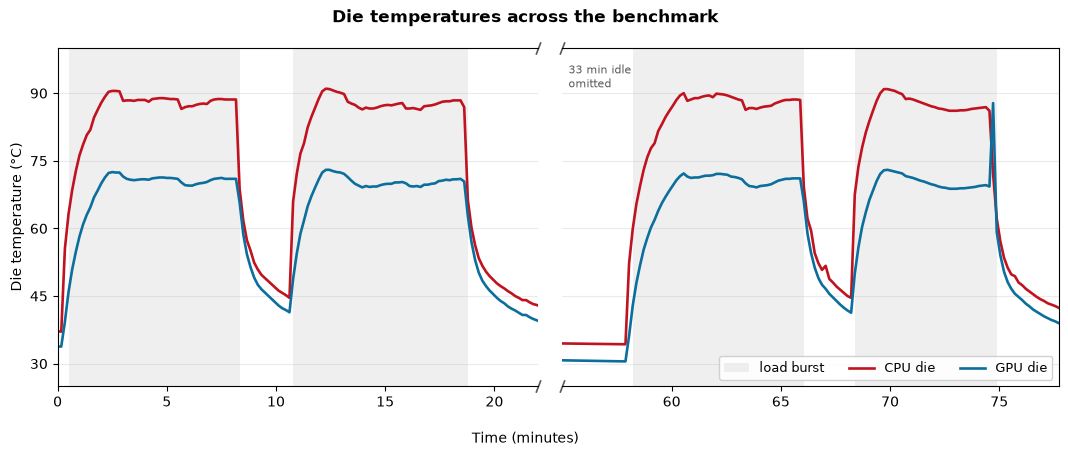

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('thermals.csv', parse_dates=['timestamp'])
df['t'] = (df.timestamp - df.timestamp.iloc[0]).dt.total_seconds()

CUT_LO, CUT_HI = 22.0, 55.0

active = (df.cpu_pct > 50) | (df.gpu_util_pct > 50)

CPU_C = '#c1121f'   # CPU die — warm red
GPU_C = '#0b6e9c'   # GPU die — cool blue (red-vs-blue stays distinct under CVD)

tmin = df.t / 60
t_end = tmin.iloc[-1]

fig, (axL, axR) = plt.subplots(
    1, 2, sharey=True, figsize=(11, 4.6),
    gridspec_kw=dict(width_ratios=[CUT_LO - tmin.iloc[0], t_end - CUT_HI],
                     wspace=0.05))

# contiguous runs of "under load", shaded on both panels (each panel's xlim clips)
runs = active.ne(active.shift()).cumsum()
labelled = set()
for _, seg in df[active.values].groupby(runs[active.values]):
    for i, ax in enumerate((axL, axR)):
        ax.axvspan(tmin[seg.index[0]], tmin[seg.index[-1]], color='0.6',
                   alpha=0.15, lw=0,
                   label=None if i in labelled else 'load burst')
        labelled.add(i)

for ax in (axL, axR):
    ax.plot(tmin, df.cpu_temp_c, color=CPU_C, lw=1.9, label='CPU die')
    ax.plot(tmin, df.gpu_temp_c, color=GPU_C, lw=1.9, label='GPU die')
    ax.grid(axis='y', alpha=0.25)

axL.set_xlim(tmin.iloc[0], CUT_LO)
axR.set_xlim(CUT_HI, t_end)
axL.set_xticks(np.arange(0, CUT_LO, 5))
axR.set_xticks(np.arange(60, t_end, 5))
axL.set_ylim(25, 100)
axL.set_yticks([30, 45, 60, 75, 90])

# hide the facing spines and mark the break with slanted ticks
axL.spines['right'].set_visible(False)
axR.spines['left'].set_visible(False)
axR.tick_params(axis='y', which='both', left=False)
brk = dict(marker=[(-1, -2.6), (1, 2.6)], markersize=9, linestyle='none',
           color='0.35', mec='0.35', mew=1.2, clip_on=False)
axL.plot([1, 1], [0, 1], transform=axL.transAxes, **brk)
axR.plot([0, 0], [0, 1], transform=axR.transAxes, **brk)
axR.annotate(f'{CUT_HI - CUT_LO:.0f} min idle\nomitted', xy=(0.012, 0.955),
             xycoords='axes fraction', ha='left', va='top', fontsize=8,
             color='0.35')

axL.set_ylabel('Die temperature (°C)')
fig.supxlabel('Time (minutes)', y=0.015, fontsize=10)
axR.legend(loc='lower right', fontsize=9, ncol=3, framealpha=0.9)
fig.suptitle('Die temperatures across the benchmark',
             fontsize=12.5, fontweight='bold', y=0.965)
# tight_layout can't account for the (unclipped) break markers — place by hand
fig.subplots_adjust(left=0.075, right=0.985, top=0.88, bottom=0.145, wspace=0.05)
plt.savefig('thermal_temps.pdf')
plt.show()